In [1]:

# ── CELL 1: Перевірка GPU + Mount Drive ──────────────────────
from google.colab import drive
drive.mount('/content/drive')

import torch
from pathlib import Path

DATA_DIR = Path("/content/drive/MyDrive/article_data")

if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU не знайдено! Увімкни T4:\n"
        "Runtime → Change runtime type → GPU → Save"
    )

print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"Files on Drive: {len(list(DATA_DIR.iterdir()))}")



Mounted at /content/drive
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
VRAM: 102.0 GB
Files on Drive: 47


In [2]:

# ── CELL 2: Install + Imports ─────────────────────────────────
# !pip install transformers torch datasets scikit-learn pandas pyarrow matplotlib

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModel,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score,
    mean_absolute_error, mean_squared_error, r2_score,
    roc_curve, precision_recall_curve
)
import warnings
warnings.filterwarnings("ignore")

DATA_DIR     = Path("/content/drive/MyDrive/article_data")
MODEL_NAME   = "jackaduma/SecBERT"
MAX_LEN      = 256
BATCH_SIZE   = 16
GRAD_ACCUM   = 4           # effective batch = 64
EPOCHS       = 3
LR           = 2e-5
WARMUP_RATIO = 0.06
RANDOM_STATE = 42
DEVICE       = torch.device("cuda")

matplotlib.rcParams.update({
    "font.family": "Liberation Sans", "font.size": 9,
    "font.weight": "normal", "axes.linewidth": 0.8,
    "lines.linewidth": 1.0, "legend.frameon": False,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 300, "savefig.dpi": 300,
    "savefig.bbox": "tight", "savefig.pad_inches": 0.05,
})
C_BLUE="#4472C4"; C_RED="#C00000"; C_ORANGE="#ED7D31"
C_GREEN="#70AD47"; C_GREY="#888888"

print("Imports OK")
print(f"Effective batch size: {BATCH_SIZE * GRAD_ACCUM}")



Imports OK
Effective batch size: 64


In [3]:

# ── CELL 3: Load FULL training data ──────────────────────────
train_df = pd.read_parquet(DATA_DIR / "train.parquet")
val_df   = pd.read_parquet(DATA_DIR / "val.parquet")
test_df  = pd.read_parquet(DATA_DIR / "test.parquet")

print(f"FULL Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}")
print(f"High-risk train: {train_df['high_risk'].mean()*100:.1f}%")
print(f"High-risk test:  {test_df['high_risk'].mean()*100:.1f}%")

# No subsample — full dataset
print(f"\nUsing FULL training set: {len(train_df):,} samples")
print(f"(Previous run used subsample of 50,000)")

y_test_reg = test_df["epss"].values
y_test_clf = test_df["high_risk"].values
y_val_reg  = val_df["epss"].values
y_val_clf  = val_df["high_risk"].values



FULL Train: 129,509  Val: 28,430  Test: 41,413
High-risk train: 6.3%
High-risk test:  1.3%

Using FULL training set: 129,509 samples
(Previous run used subsample of 50,000)


In [4]:

# ── CELL 4: Tokenizer + Dataset ───────────────────────────────
print("\nLoading SecBERT tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class CVEDataset(Dataset):
    def __init__(self, texts, labels_reg, labels_clf, max_len=MAX_LEN):
        self.texts      = texts
        self.labels_reg = labels_reg
        self.labels_clf = labels_clf
        self.max_len    = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
            "label_reg":      torch.tensor(self.labels_reg[idx],
                                           dtype=torch.float),
            "label_clf":      torch.tensor(self.labels_clf[idx],
                                           dtype=torch.float),
        }

train_dataset = CVEDataset(
    train_df["text_minimal"].fillna("").values,
    train_df["epss"].values,
    train_df["high_risk"].values,
)
val_dataset = CVEDataset(
    val_df["text_minimal"].fillna("").values,
    val_df["epss"].values,
    val_df["high_risk"].values,
)
test_dataset = CVEDataset(
    test_df["text_minimal"].fillna("").values,
    test_df["epss"].values,
    test_df["high_risk"].values,
)

# Use more workers for large dataset
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                           shuffle=True, num_workers=4,
                           pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE*2,
                           shuffle=False, num_workers=4,
                           pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE*2,
                           shuffle=False, num_workers=4,
                           pin_memory=True)

print(f"Batches: train={len(train_loader)} "
      f"val={len(val_loader)} test={len(test_loader)}")
print(f"Steps per epoch: {len(train_loader)}")
print(f"Gradient accumulation steps: {GRAD_ACCUM}")
print(f"Effective steps per epoch: {len(train_loader) // GRAD_ACCUM}")




Loading SecBERT tokenizer...


config.json:   0%|          | 0.00/467 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Batches: train=8095 val=889 test=1295
Steps per epoch: 8095
Gradient accumulation steps: 4
Effective steps per epoch: 2023


In [5]:

# ── CELL 5: Model ─────────────────────────────────────────────
class SecBERTPredictor(nn.Module):
    def __init__(self, model_name, dropout=0.1):
        super().__init__()
        self.encoder  = AutoModel.from_pretrained(model_name)
        hidden        = self.encoder.config.hidden_size
        self.dropout  = nn.Dropout(dropout)
        self.reg_head = nn.Sequential(
            nn.Linear(hidden, 1), nn.Sigmoid()
        )
        self.clf_head = nn.Linear(hidden, 1)

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids,
                           attention_mask=attention_mask)
        cls = self.dropout(out.last_hidden_state[:, 0, :])
        return self.reg_head(cls).squeeze(-1), \
               self.clf_head(cls).squeeze(-1)

print("\nLoading SecBERT model...")
model = SecBERTPredictor(MODEL_NAME).to(DEVICE)

# Enable gradient checkpointing to save VRAM on large dataset
model.encoder.gradient_checkpointing_enable()

n_params = sum(p.numel() for p in model.parameters()
               if p.requires_grad)
print(f"Trainable params: {n_params:,}")
print(f"Gradient checkpointing: enabled")




Loading SecBERT model...


model.safetensors:   0%|          | 0.00/336M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: jackaduma/SecBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Trainable params: 83,452,418
Gradient checkpointing: enabled


In [6]:

# ── CELL 6: Training setup ────────────────────────────────────
neg = (train_df["high_risk"] == 0).sum()
pos = (train_df["high_risk"] == 1).sum()
pos_weight = torch.tensor([neg / pos],
                           dtype=torch.float).to(DEVICE)
print(f"pos_weight: {pos_weight.item():.2f}")

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)

# Steps with gradient accumulation
effective_steps  = (len(train_loader) // GRAD_ACCUM) * EPOCHS
warmup_steps     = int(effective_steps * WARMUP_RATIO)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=effective_steps
)

loss_reg_fn = nn.MSELoss()
loss_clf_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print(f"Effective training steps: {effective_steps}")
print(f"Warmup steps: {warmup_steps}")
print(f"Estimated time on T4: ~{effective_steps * 0.8 / 60:.0f} min")



pos_weight: 14.93
Effective training steps: 6069
Warmup steps: 364
Estimated time on T4: ~81 min


In [7]:

# ── CELL 7: Training loop with gradient accumulation ─────────
print(f"\nTraining {EPOCHS} epochs on FULL dataset ({len(train_df):,} samples)")
print("="*60)

train_losses = []
val_aucs     = []
best_val_auc = 0.0
best_state   = None

for epoch in range(EPOCHS):
    model.train()
    epoch_loss  = 0.0
    step_count  = 0
    optimizer.zero_grad()

    for step, batch in enumerate(train_loader):
        input_ids = batch["input_ids"].to(DEVICE)
        attn_mask = batch["attention_mask"].to(DEVICE)
        lab_reg   = batch["label_reg"].to(DEVICE)
        lab_clf   = batch["label_clf"].to(DEVICE)

        pred_reg, logits = model(input_ids, attn_mask)
        loss = (loss_reg_fn(pred_reg, lab_reg) +
                loss_clf_fn(logits, lab_clf)) / GRAD_ACCUM
        loss.backward()
        epoch_loss += loss.item() * GRAD_ACCUM

        # Gradient accumulation step
        if (step + 1) % GRAD_ACCUM == 0:
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
            step_count += 1

            if step_count % 100 == 0:
                print(f"  Epoch {epoch+1}/{EPOCHS} "
                      f"Step {step_count}/{effective_steps//EPOCHS} "
                      f"Loss={loss.item()*GRAD_ACCUM:.4f}")

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    # Validation
    model.eval()
    val_probs = []; val_preds = []
    with torch.no_grad():
        for batch in val_loader:
            pr, lg = model(
                batch["input_ids"].to(DEVICE),
                batch["attention_mask"].to(DEVICE)
            )
            val_probs.extend(torch.sigmoid(lg).cpu().numpy())
            val_preds.extend(pr.cpu().numpy())

    val_auc = roc_auc_score(y_val_clf, np.array(val_probs))
    val_mae = mean_absolute_error(y_val_reg, np.array(val_preds))
    val_aucs.append(val_auc)

    print(f"\nEpoch {epoch+1} done: "
          f"loss={avg_loss:.4f}  "
          f"val AUC={val_auc:.4f}  "
          f"val MAE={val_mae:.4f}")

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_state   = {k: v.clone()
                        for k, v in model.state_dict().items()}
        print(f"  ★ Best model saved (val AUC={best_val_auc:.4f})")

# Save model state
torch.save(best_state,
           DATA_DIR / "secbert_full_best_state.pt")
print(f"\nBest model saved to Drive. Val AUC: {best_val_auc:.4f}")




Training 3 epochs on FULL dataset (129,509 samples)


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


  Epoch 1/3 Step 100/2023 Loss=1.3869
  Epoch 1/3 Step 200/2023 Loss=0.6694
  Epoch 1/3 Step 300/2023 Loss=1.9019
  Epoch 1/3 Step 400/2023 Loss=0.2387
  Epoch 1/3 Step 500/2023 Loss=0.7150
  Epoch 1/3 Step 600/2023 Loss=0.1909
  Epoch 1/3 Step 700/2023 Loss=0.4694
  Epoch 1/3 Step 800/2023 Loss=2.7280
  Epoch 1/3 Step 900/2023 Loss=2.4215
  Epoch 1/3 Step 1000/2023 Loss=1.7746
  Epoch 1/3 Step 1100/2023 Loss=0.3545
  Epoch 1/3 Step 1200/2023 Loss=7.1946
  Epoch 1/3 Step 1300/2023 Loss=0.1414
  Epoch 1/3 Step 1400/2023 Loss=0.6983
  Epoch 1/3 Step 1500/2023 Loss=1.9536
  Epoch 1/3 Step 1600/2023 Loss=0.1621
  Epoch 1/3 Step 1700/2023 Loss=0.2592
  Epoch 1/3 Step 1800/2023 Loss=0.7121
  Epoch 1/3 Step 1900/2023 Loss=0.8319
  Epoch 1/3 Step 2000/2023 Loss=0.8482

Epoch 1 done: loss=1.0330  val AUC=0.8667  val MAE=0.0461
  ★ Best model saved (val AUC=0.8667)
  Epoch 2/3 Step 100/2023 Loss=0.5269
  Epoch 2/3 Step 200/2023 Loss=0.2825
  Epoch 2/3 Step 300/2023 Loss=0.4909
  Epoch 2/3 Step 4

In [8]:

# ── CELL 8: Test evaluation ───────────────────────────────────
print("\n=== SecBERT FULL — Test evaluation ===")
model.load_state_dict(best_state)
model.eval()

test_probs = []; test_preds = []
with torch.no_grad():
    for batch in test_loader:
        pr, lg = model(
            batch["input_ids"].to(DEVICE),
            batch["attention_mask"].to(DEVICE)
        )
        test_probs.extend(torch.sigmoid(lg).cpu().numpy())
        test_preds.extend(pr.cpu().numpy())

test_probs = np.array(test_probs)
test_preds = np.array(test_preds)
test_pred_clf = (test_probs >= 0.5).astype(int)

mae3f  = mean_absolute_error(y_test_reg, test_preds)
rmse3f = np.sqrt(mean_squared_error(y_test_reg, test_preds))
r2_3f  = r2_score(y_test_reg, test_preds)
auc3f  = roc_auc_score(y_test_clf, test_probs)
prauc3f = average_precision_score(y_test_clf, test_probs)
prec3f = precision_score(y_test_clf, test_pred_clf, zero_division=0)
rec3f  = recall_score(y_test_clf, test_pred_clf, zero_division=0)
f1_3f  = f1_score(y_test_clf, test_pred_clf, zero_division=0)

print(f"REGRESSION:")
print(f"  MAE  = {mae3f:.4f}  (50k: 0.0180)")
print(f"  RMSE = {rmse3f:.4f}  (50k: 0.0724)")
print(f"  R2   = {r2_3f:.4f}  (50k: -0.6655)")
print(f"\nCLASSIFICATION:")
print(f"  AUC-ROC   = {auc3f:.4f}  (50k: 0.8657)")
print(f"  PR-AUC    = {prauc3f:.4f}  (50k: 0.1107)")
print(f"  Precision = {prec3f:.4f}  (50k: 0.1361)")
print(f"  Recall    = {rec3f:.4f}  (50k: 0.3989)")
print(f"  F1        = {f1_3f:.4f}  (50k: 0.2030)")

np.save(DATA_DIR / "m3_full_test_probs.npy", test_probs)
np.save(DATA_DIR / "m3_full_test_preds.npy", test_preds)
print("\nM3 full results saved to Drive.")




=== SecBERT FULL — Test evaluation ===
REGRESSION:
  MAE  = 0.0268  (50k: 0.0180)
  RMSE = 0.0677  (50k: 0.0724)
  R2   = -0.4559  (50k: -0.6655)

CLASSIFICATION:
  AUC-ROC   = 0.8775  (50k: 0.8657)
  PR-AUC    = 0.1111  (50k: 0.1107)
  Precision = 0.0673  (50k: 0.1361)
  Recall    = 0.7213  (50k: 0.3989)
  F1        = 0.1232  (50k: 0.2030)

M3 full results saved to Drive.



=== Updating Figures 8, 9 with full M3 ===
M2 probs loaded.


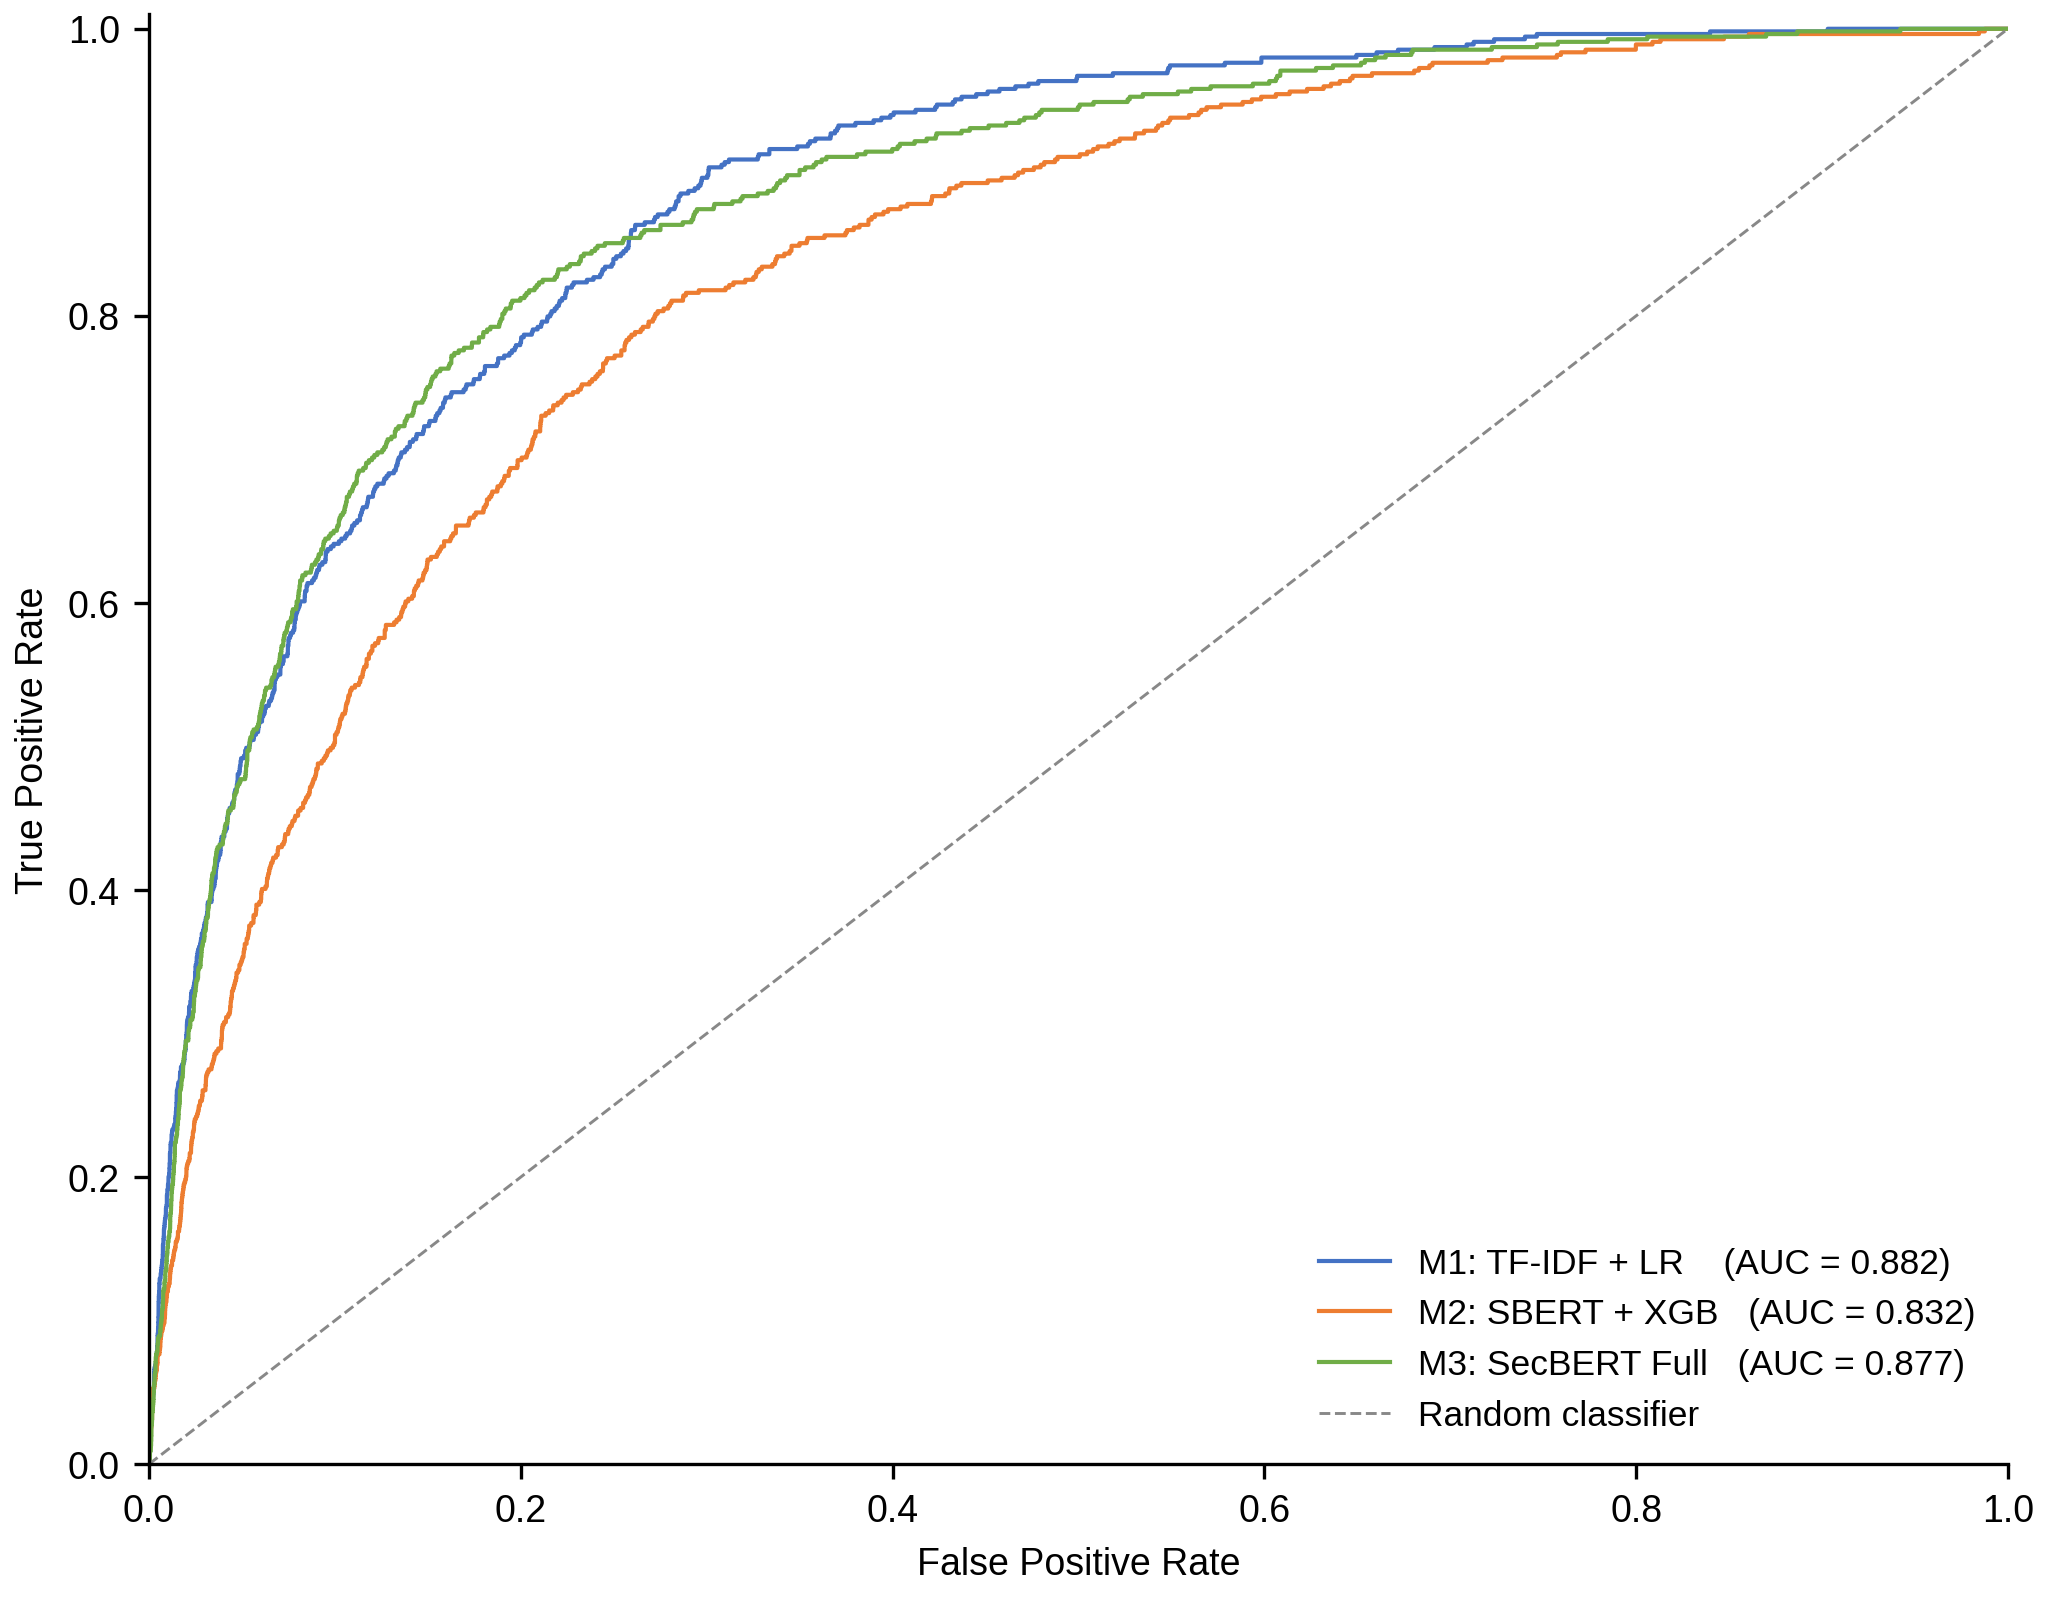

Figure 8 updated.


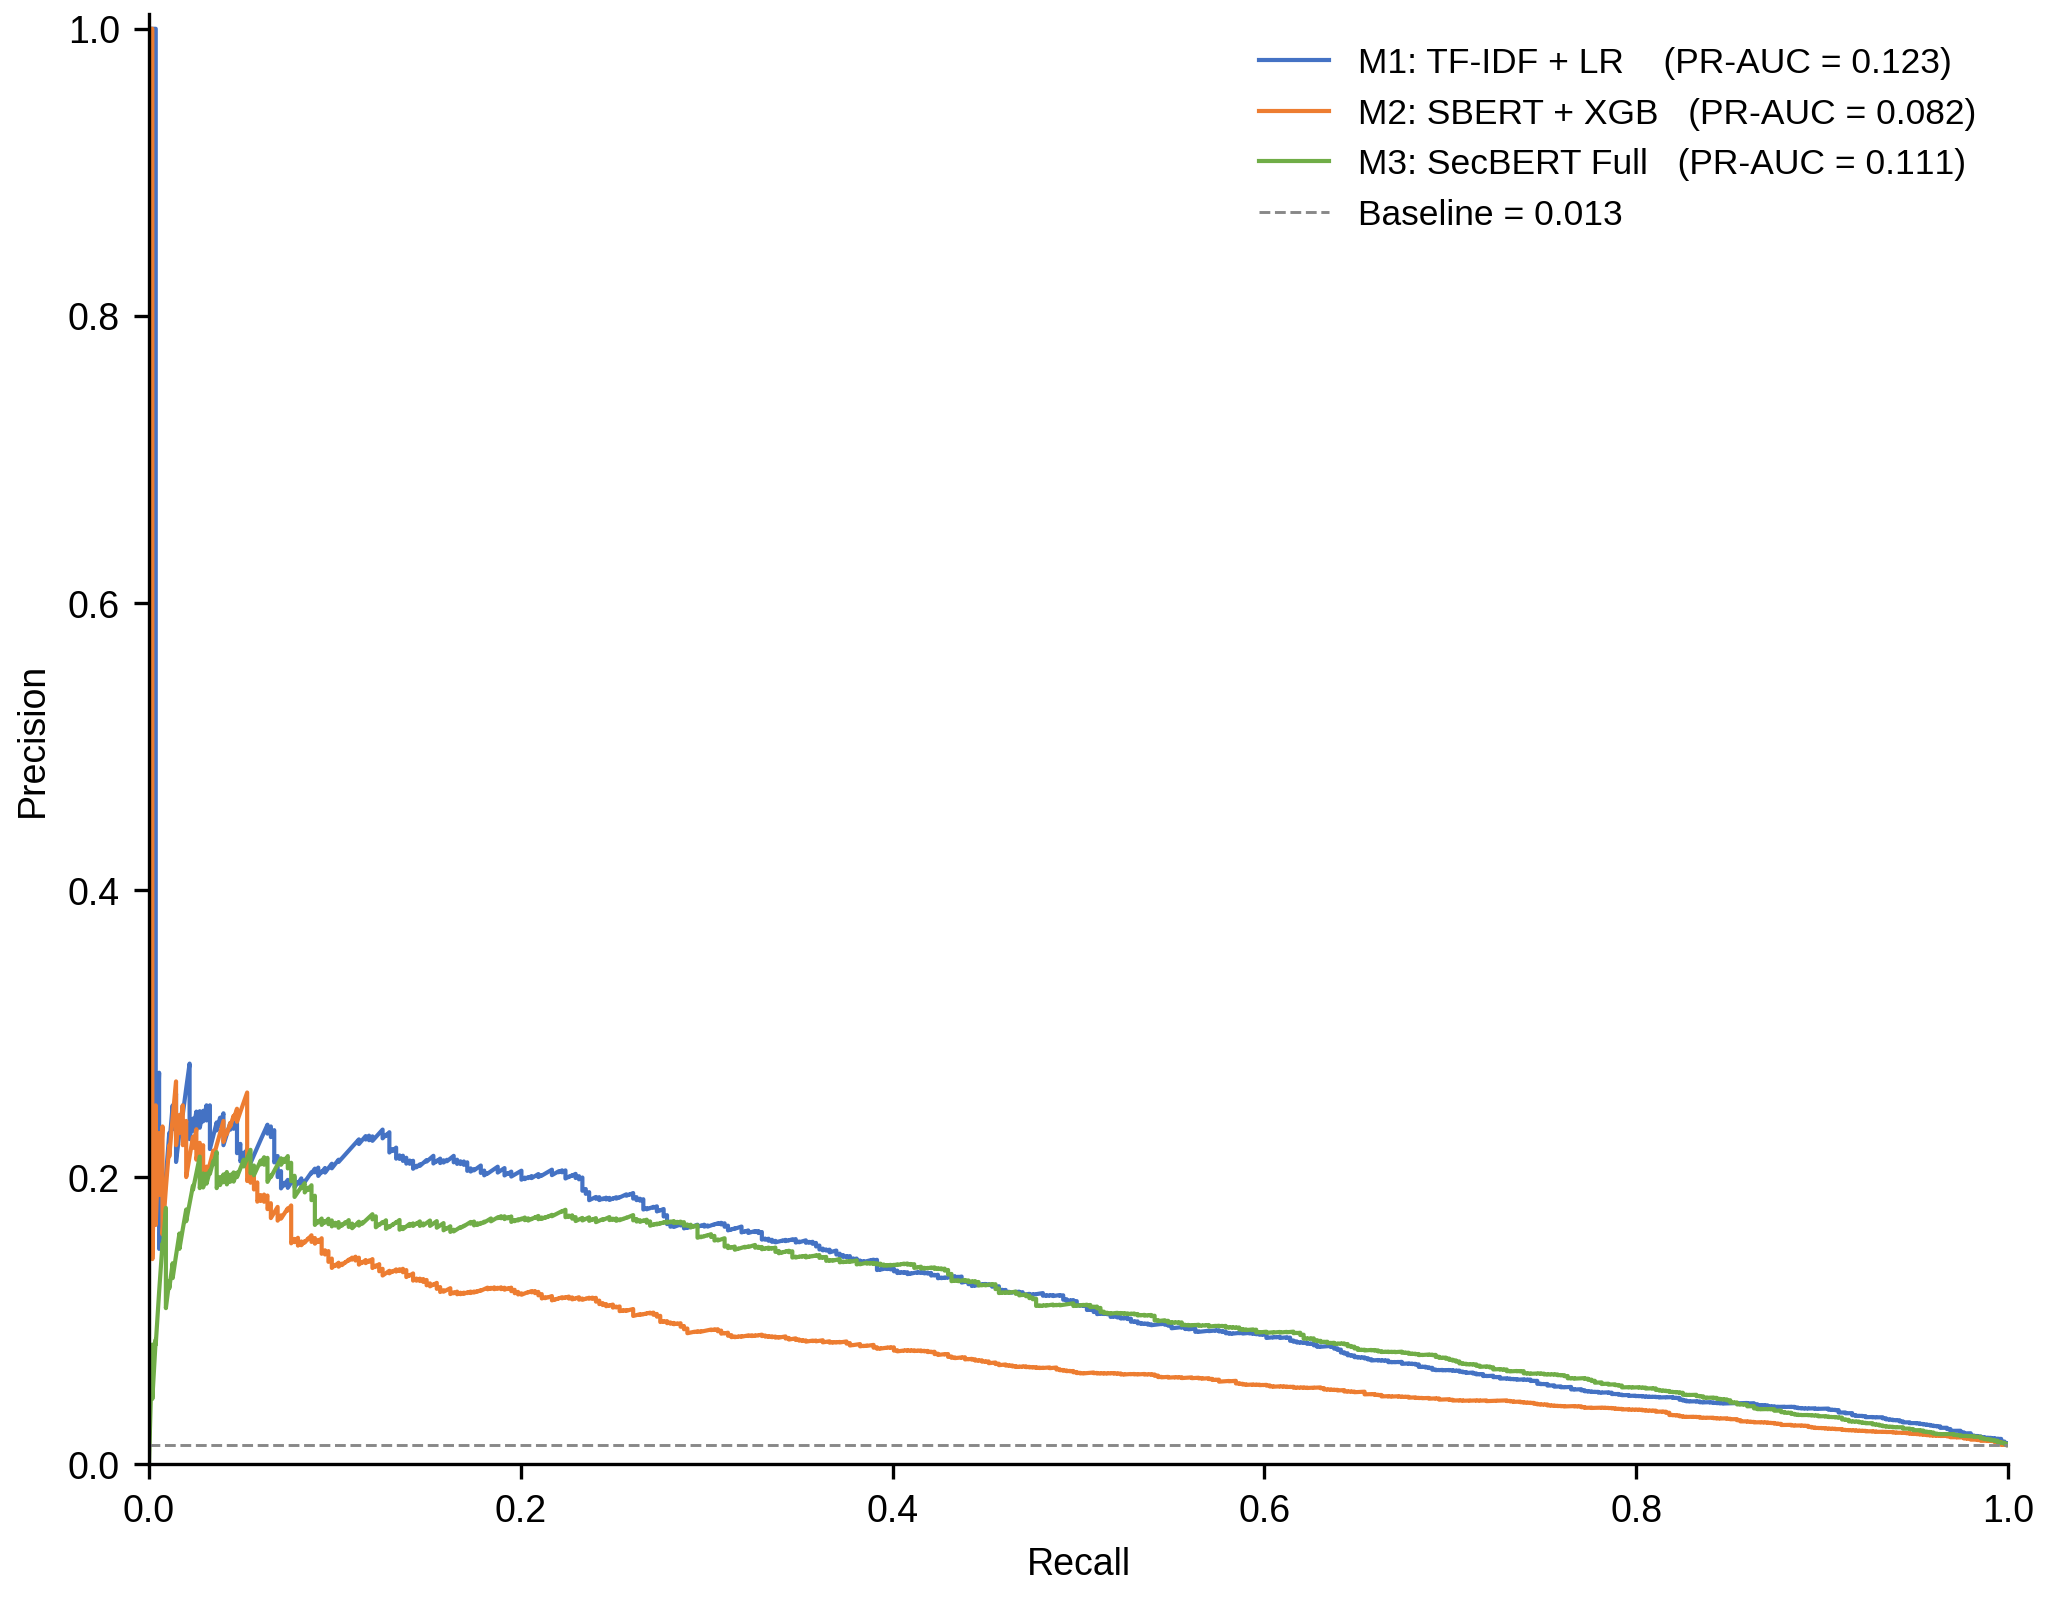

Figure 9 updated.


In [9]:

# ── CELL 9: Updated figures with full M3 ─────────────────────
print("\n=== Updating Figures 8, 9 with full M3 ===")

# Rebuild M1
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

X_tr = train_df["text_full"].fillna("").values
X_te = test_df["text_full"].fillna("").values
y_tr = train_df["high_risk"].values

tfidf_f = TfidfVectorizer(ngram_range=(1,2), max_features=50_000,
                            sublinear_tf=True, min_df=2)
Xtr_f = tfidf_f.fit_transform(X_tr)
Xte_f = tfidf_f.transform(X_te)
lr_f  = LogisticRegression(C=1.0, max_iter=1000,
                             class_weight="balanced",
                             random_state=42, solver="saga", n_jobs=-1)
lr_f.fit(Xtr_f, y_tr)
m1_probs = lr_f.predict_proba(Xte_f)[:,1]

# Load M2
try:
    m2_probs = np.load(DATA_DIR / "m2_test_probs.npy")
    has_m2 = True
    print("M2 probs loaded.")
except:
    has_m2 = False
    print("M2 probs not found.")

# Figure 8 — ROC curves (updated)
fig8, ax = plt.subplots(figsize=(7, 5.5))
fpr1, tpr1, _ = roc_curve(y_test_clf, m1_probs)
auc1 = roc_auc_score(y_test_clf, m1_probs)
ax.plot(fpr1, tpr1, color=C_BLUE, lw=1.0,
        label=f"M1: TF-IDF + LR    (AUC = {auc1:.3f})")
if has_m2:
    fpr2, tpr2, _ = roc_curve(y_test_clf, m2_probs)
    auc2 = roc_auc_score(y_test_clf, m2_probs)
    ax.plot(fpr2, tpr2, color=C_ORANGE, lw=1.0,
            label=f"M2: SBERT + XGB   (AUC = {auc2:.3f})")
fpr3, tpr3, _ = roc_curve(y_test_clf, test_probs)
ax.plot(fpr3, tpr3, color=C_GREEN, lw=1.0,
        label=f"M3: SecBERT Full   (AUC = {auc3f:.3f})")
ax.plot([0,1],[0,1], color=C_GREY, lw=0.7, linestyle="--",
        label="Random classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right", fontsize=8.5)
ax.set_xlim(0,1); ax.set_ylim(0,1.01)
plt.tight_layout()
plt.savefig(DATA_DIR / "fig08_roc_curves.pdf")
plt.savefig(DATA_DIR / "fig08_roc_curves.png", dpi=300)
plt.show()
print("Figure 8 updated.")

# Figure 9 — PR curves (updated)
fig9, ax = plt.subplots(figsize=(7, 5.5))
baseline = y_test_clf.mean()
prec1r, rec1r, _ = precision_recall_curve(y_test_clf, m1_probs)
prauc1 = average_precision_score(y_test_clf, m1_probs)
ax.plot(rec1r, prec1r, color=C_BLUE, lw=1.0,
        label=f"M1: TF-IDF + LR    (PR-AUC = {prauc1:.3f})")
if has_m2:
    prec2r, rec2r, _ = precision_recall_curve(y_test_clf, m2_probs)
    prauc2 = average_precision_score(y_test_clf, m2_probs)
    ax.plot(rec2r, prec2r, color=C_ORANGE, lw=1.0,
            label=f"M2: SBERT + XGB   (PR-AUC = {prauc2:.3f})")
prec3r, rec3r, _ = precision_recall_curve(y_test_clf, test_probs)
ax.plot(rec3r, prec3r, color=C_GREEN, lw=1.0,
        label=f"M3: SecBERT Full   (PR-AUC = {prauc3f:.3f})")
ax.axhline(baseline, color=C_GREY, lw=0.7, linestyle="--",
           label=f"Baseline = {baseline:.3f}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(loc="upper right", fontsize=8.5)
ax.set_xlim(0,1); ax.set_ylim(0,1.01)
plt.tight_layout()
plt.savefig(DATA_DIR / "fig09_pr_curves.pdf")
plt.savefig(DATA_DIR / "fig09_pr_curves.png", dpi=300)
plt.show()
print("Figure 9 updated.")



In [10]:

# ── CELL 10: Final summary ────────────────────────────────────
print("\n" + "="*70)
print("FINAL RESULTS — ALL THREE METHODS (M3 = FULL dataset)")
print("="*70)
print(f"\nREGRESSION (test set):")
print(f"{'Method':<28} {'MAE':>8} {'RMSE':>8} {'R2':>8}")
print("-"*54)
print(f"{'M1: TF-IDF + Ridge':<28} {0.0330:>8.4f} {0.0640:>8.4f} {-0.2993:>8.4f}")
print(f"{'M2: SBERT + XGB':<28} {0.0316:>8.4f} {0.0627:>8.4f} {-0.2476:>8.4f}")
print(f"{'M3: SecBERT Full':<28} {mae3f:>8.4f} {rmse3f:>8.4f} {r2_3f:>8.4f}")
print(f"\nCLASSIFICATION (test set):")
print(f"{'Method':<28} {'AUC-ROC':>8} {'PR-AUC':>8} "
      f"{'Prec':>8} {'Recall':>8} {'F1':>8}")
print("-"*70)
print(f"{'M1: TF-IDF + LR':<28} {0.8820:>8.4f} {0.1234:>8.4f} "
      f"{0.0695:>8.4f} {0.6812:>8.4f} {0.1261:>8.4f}")
print(f"{'M2: SBERT + XGB':<28} {0.8323:>8.4f} {0.0818:>8.4f} "
      f"{0.0614:>8.4f} {0.5428:>8.4f} {0.1104:>8.4f}")
print(f"{'M3: SecBERT Full':<28} {auc3f:>8.4f} {prauc3f:>8.4f} "
      f"{prec3f:>8.4f} {rec3f:>8.4f} {f1_3f:>8.4f}")

print(f"\nComparison M3 Full vs M3 50k subsample:")
print(f"  AUC-ROC:  {auc3f:.4f} vs 0.8657  "
      f"({'↑' if auc3f > 0.8657 else '↓'}"
      f"{abs(auc3f-0.8657):.4f})")
print(f"  PR-AUC:   {prauc3f:.4f} vs 0.1107  "
      f"({'↑' if prauc3f > 0.1107 else '↓'}"
      f"{abs(prauc3f-0.1107):.4f})")
print(f"  F1:       {f1_3f:.4f} vs 0.2030  "
      f"({'↑' if f1_3f > 0.2030 else '↓'}"
      f"{abs(f1_3f-0.2030):.4f})")
print(f"\nAll files saved to Drive.")



FINAL RESULTS — ALL THREE METHODS (M3 = FULL dataset)

REGRESSION (test set):
Method                            MAE     RMSE       R2
------------------------------------------------------
M1: TF-IDF + Ridge             0.0330   0.0640  -0.2993
M2: SBERT + XGB                0.0316   0.0627  -0.2476
M3: SecBERT Full               0.0268   0.0677  -0.4559

CLASSIFICATION (test set):
Method                        AUC-ROC   PR-AUC     Prec   Recall       F1
----------------------------------------------------------------------
M1: TF-IDF + LR                0.8820   0.1234   0.0695   0.6812   0.1261
M2: SBERT + XGB                0.8323   0.0818   0.0614   0.5428   0.1104
M3: SecBERT Full               0.8775   0.1111   0.0673   0.7213   0.1232

Comparison M3 Full vs M3 50k subsample:
  AUC-ROC:  0.8775 vs 0.8657  (↑0.0118)
  PR-AUC:   0.1111 vs 0.1107  (↑0.0004)
  F1:       0.1232 vs 0.2030  (↓0.0798)

All files saved to Drive.


In [11]:
# ── CELL 11: Precision@k для M3 Full ─────────────────────────
import numpy as np
import pandas as pd
from pathlib import Path

DATA_DIR = Path("/content/drive/MyDrive/article_data")
test_df  = pd.read_parquet(DATA_DIR / "test.parquet")
y_test   = test_df["high_risk"].values

m3_probs = np.load(DATA_DIR / "m3_full_test_probs.npy")

def precision_at_k(y_true, y_prob, k_pct):
    k = max(1, int(len(y_true) * k_pct / 100))
    top_idx = np.argsort(y_prob)[::-1][:k]
    return y_true[top_idx].mean()

base = y_test.mean()
print(f"Baseline: {base*100:.2f}%")
print(f"\nM3 Full precision@k:")
for k in [1, 2, 5, 10, 20]:
    p = precision_at_k(y_test, m3_probs, k)
    lift = p / base
    print(f"  @{k:2d}%: {p*100:.1f}%  (lift {lift:.1f}x)")

Baseline: 1.33%

M3 Full precision@k:
  @ 1%: 16.9%  (lift 12.8x)
  @ 2%: 17.3%  (lift 13.0x)
  @ 5%: 12.1%  (lift 9.1x)
  @10%: 8.5%  (lift 6.4x)
  @20%: 5.3%  (lift 4.0x)
